In [64]:
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.integrate as integrate
from scipy.interpolate import PchipInterpolator
from scipy.integrate import simpson 

from __future__ import division, print_function, absolute_import

from numpy import cos, inf, zeros, array, exp, conj, nan, isnan, pi, sin, seterr
from numpy.lib.scimath import arcsin

import numpy as np

#physical constants 
h_J = 6.626 * 1E-34 #planck's constant in Joule-seconds
h_eV = 4.136 * 1E-15 #planck's constant in eV-seconds 
c = 3*1E8 #speed of light in m/s 
kb_J = 1.3806 * 1E-23 #boltzmann constant in  Joule/Kelvin 
kb_eV = 8.6173 * 1E-5 #boltzmannc constant in eV/Kelvin 
q = 1.602 * 1E-19 #charge of an electron in Coulombs 
b = 2.89771955 * 1E-3 #Wien's displacement constant [m * Kelvin] given here: https://en.wikipedia.org/wiki/Black-body_radiation#Planck's_law_of_black-body_radiation

T_emitter = np.array([1000, 1200, 1400, 1600, 1800, 2000]) + 273.15 #emitter temperatures converted from Celsius to Kelvin  
Eg_Array = np.array([1.1, 0.9, 0.73, 0.6, 0.53, 0.35]) #Bandgap energies in eV 
lam_min = 327 * 1E-9 #smallest wavelength to consider according to the paper is 327 nm. Writing this in terms of meters --> relevant to NBE 
T_c = 300 #300 Kelvin is the T_cell 

P_deriv_target = 0.00 #use this to find the voltage that leads to maximum power

    #functions 
def lam_Bandgap(EG_eV): #need to put in bandgap energy in units of eV so that this is in meters 
    return h_eV * c / EG_eV 
    
def lam_BB_peak(Temperature): #From Wien's Displacement Law, the peak wavelength of the BB spectrum can be determined
    return (b) / Temperature #Peak wavelength of the blackbody spectrum in units of meters 

def BB_spectrum(lam, T):
    numerator = (2 * h_J * c**2 )
    denominator = (lam)**5 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 )
    return numerator/denominator   #has units of W/m^3 if you input lam in [m]


def BB_spectrum_SBS(lam, lam_Eg, T): #SBS --> Sub-bandgap suppression. Any wavelength longer than lam_EG will not be included. 
    BB_rad_SBS = []#blackbody radiance w/ SBS. REMEMBER THAT I WROTE THIS SUCH THAT YOU NEED TO PUT THE WAVELENGTHS IN [m] 
    
    for wl in lam:
        if wl <= lam_Eg:
            numerator = (2 * h_J * c**2 )
        else:
            numerator = 0 
            
        denominator = (wl)**5 * ( np.exp( (h_J * c) / (wl * kb_J * T) ) - 1 )

        val = numerator/denominator 
        BB_rad_SBS.append(val) 

    BB_rad_SBS = np.array(BB_rad_SBS) 
    
    return BB_rad_SBS #has units of W/m^3 if you input lam in [m]
    
def BB_spectrum_NBE(lam, lam_min, lam_Eg, T):
    BB_full = BB_spectrum(lam, T)                                          # full spectrum, shape (n,)
    mask = (lam[None, :] >= lam_min[:, None]) & (lam[None, :] <= lam_Eg)   # shape (m, n)
    return BB_full[None, :] * mask                                         # zeroes out everything outside each window
    #in units of W/m^3 as long as wavelengths are in units of meters 

def n_B(lam, T): #temperature should be input in Kelvin and lam should be input in meters 
    numerator = (2 * c) #m/s 
    denominator = (lam)**4 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 ) #in units of m^4
    return numerator/denominator   #has units of s^-1 * m^3 if you input lam in [m] 

def n_B_SBS(lam, lam_Eg, T): #temperature should be input in Kelvin and lam should be input in meters 

    n_B_SBS_array = []
    
    for wl in lam:
        if wl <= lam_Eg:
             numerator = (2 * c) #m/s
        else:
            numerator = 0 
 
        denominator = (wl)**4 * ( np.exp( (h_J * c) / (wl * kb_J * T) ) - 1 ) #in units of m^4

        val = numerator/denominator 
        n_B_SBS_array.append(val) 

    n_B_SBS_array = np.array(n_B_SBS_array) 
                             
    return n_B_SBS_array #has units of s^-1 * m^3 if you input lam in [m] 

def n_B_NBE(lam, lam_min, lam_Eg, T):
    nB_full = n_B(lam, T)
    mask = (lam[None, :] >= lam_min[:, None]) & (lam[None, :] <= lam_Eg)
    return nB_full[None, :] * mask


def EQE(lam, lam_Eg): #assumes that lam is in nanometers. I'll apply this to section #2 and #3 -- Bryant at 12:22 pm (7/13/26) 
    return np.where(lam < lam_Eg, 1, 0) #first entry in the argument is the condition, second is the result if it's met, and third is the result when it's not met
    
def P_derivative(J_L, J_0, V):
    return (J_L + J_0) - (J_0) * np.exp(q * V / (kb_J * T_c)) * (1 + q * V / (kb_J * T_c))

def J(J_L, J_0, V):
    return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c)) - 1)

def P_cell_WCM2(n_B_array_LIGHT, n_B_array_DARK, wl_array, EQE_SF, emissivity): 
    #n_B spectra for light an dark, wavelengths of emitter spectrum, EQE of cell, and emissivity
    
    integrand_JL = q * np.pi * emissivity * n_B_array_LIGHT * EQE_SF #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                     #integrating it will give A/m^2 which is appropriate for current density. 

    integrand_J0 = q * np.pi * n_B_array_DARK * EQE_SF

    J_L = simpson(integrand_JL, x=wl_array) #light-induced current density given in A/m^2 

    J_0 = simpson(integrand_J0, x=wl_array) #dark-current density given in A/m^2 

    V_oc = (np.log((J_L / J_0) + 1)) * kb_eV * T_c #in units of Volts, the open circuit voltage (I = 0)

    V_vals = np.linspace(0, V_oc, 200) #creates the array of possible voltage values for IV curve

    P_derivs = P_derivative(J_L, J_0, V_vals) #calculates the derivatives of Power wrt Voltage 
    
    differences = np.abs(P_derivs - P_deriv_target) #apart of finding where the voltage that produces P_max is  
    
    idx = np.argmin(differences) 
    
    V_pmax = V_vals[idx] #voltage that produes P_max 
    
    J_pmax = J(J_L, J_0, V_pmax) #Current-density in A/m^2 that produces P_max 
    
    P_max = J_pmax * V_pmax # Maximum Cell Power in units of W/m^2 

    P_cell = P_max * 1E-4 #Maximum cell power in units of W/cm^2 

    return P_cell 


#We'll be using the blackbody spectrum the entire time. Wavelengths will be in units of nm. 
#For ABC --> Full Spectrum
#For DEF --> BB spectrum with sub-bandgap suppression
#For GHI --> BB spectrum with sub-bandgap suppression and Narrow-band emission 

    
emissivity = 1 #Since we're dealing with the blackbody spectrum the emissivity is just straight up 1.

    #this is for reproducing 1b and 1c 
P_cell_array = np.zeros((len(Eg_Array), len(T_emitter))) #Power for each pair of emitter temp and bandgap energy 
eta_array = np.zeros((len(Eg_Array), len(T_emitter))) #efficiency for each pair 
                                                      #np.zeros(a) --> 1D array of zeros, with a # of entries
                                                      #np.zeros((a,b)) --> 2D array of zeros with dimensions (a,b) \

                                                      #remember the arrays are defined as m x n, m = rows, n = columns. 

P_emit_array = np.zeros((len(Eg_Array), len(T_emitter)))

    #this is for reproducing 1e and 1f
P_cell_array_SBS = np.zeros((len(Eg_Array), len(T_emitter)))
eta_array_SBS = np.zeros((len(Eg_Array), len(T_emitter)))
P_emit_array_SBS = np.zeros((len(Eg_Array), len(T_emitter)))

    #this is for reproducing 1h and 1i
P_cell_array_NBE = np.zeros((len(Eg_Array), len(T_emitter))) #NBE --> narrow band emission (from [lam_Eg - delta_lambda, lam_Eg])
eta_array_NBE = np.zeros((len(Eg_Array), len(T_emitter)))
P_emit_array_NBE = np.zeros((len(Eg_Array), len(T_emitter)))

lam_windows = np.zeros((len(Eg_Array), len(T_emitter))) #so that I can determine what the windows are. This will be in [m] 

#Running the calculations for all 6 plots. 

for i, temp in enumerate(T_emitter):
    for j, Energy in enumerate(Eg_Array):

            #Grabbing bandgap energy for EQE, SBS, and later, the window 
        lam_Eg = lam_Bandgap(Energy) # should come out to be in units of meters for the wavelength, determines what portion is sub-bandgap 
        
        lam_Eg_nm = lam_Eg * 1E9 #converting it to nm 

        lam_min_vals = np.linspace(lam_min, lam_Eg, 1000) #initializing 1000 points, so we're testing 1000 possible windows for NBE.
                                                          #units of meters! 

            #blackbody spectrum construction

        wl_BB_peak = lam_BB_peak(temp) #calculating the peak-wavelength of the spectrum 

        wl_array = np.linspace(1E-9, wl_BB_peak * 20, 10000) #wavelength array is also in units of meters, 
                                                             # * 20 and 10000 points achieves good accuracy 

        wl_array_nm = wl_array * 1E9 #converting it to nm for later 

        BB_radiance = BB_spectrum(wl_array, temp) #will have units of W / m^3

        BB_radiance_SBS = BB_spectrum_SBS(wl_array, lam_Eg, temp) #BB spectrum w/ sub-bandgap suppression 

        BB_radiance_NBE = BB_spectrum_NBE(wl_array, lam_min_vals, lam_Eg, temp) # keep in mind that this is going to have 500 rows, and like 10000 points in each row, 
                                                                             # but majority of the values are going to be 0 
                                                                    
        
            #setting things up for integration (simpsons rule approach over scipy.integrate) 

        integrand = np.pi * emissivity * BB_radiance # BB_rad = [W/m^3] --> integrand has units of rad(unitless) * [W/m^3] 

        integrand_SBS = np.pi * emissivity * BB_radiance_SBS #[W/m^3] * rads 

        integrand_NBE = np.pi * emissivity * BB_radiance_NBE #same dimensions as BB_radiance_NBE 

        P_emit = simpson(integrand, x = wl_array) #emitted power in units of W/m^2 

        P_emit_SBS = simpson(integrand_SBS, x = wl_array) 

        P_emit_NBE_vals = simpson(integrand_NBE, x = wl_array) #again, keep in mind that this is going to be an (m,) array. I need to index into this 
                                                               #with a third index because i belongs to T_emitter and j belongs to Eg_Array
        
                             
        P_emit_cm2 = P_emit * 1E-4 #emitted power in units of W/cm^2 

        P_emit_SBS_cm2 = P_emit_SBS * 1E-4 #[W/cm^2] 

        P_emit_NBE_cm2 = P_emit_NBE_vals * 1E-4 #[W/cm^2] --> We can't assign P_emit_array_NBE[j,i] until the very end. 

        P_emit_array[j,i] = P_emit_cm2

        P_emit_array_SBS[j,i] = P_emit_SBS_cm2 
        

            #These use the full blackbody spectrum 
        n_B_array_LIGHT = n_B(wl_array, temp) #Blackbody Spectral Photon Radiance, as defined in Declan's slides on 08/02/23.
        n_B_array_DARK = n_B(wl_array, T_c) 

            #These use the spectrum w/ Sub-bandgap suppression
        n_B_array_LIGHT_SBS = n_B_SBS(wl_array, lam_Eg, temp) 
        n_B_array_DARK_SBS = n_B_SBS(wl_array, lam_Eg, T_c) 

            #These use the narrow-band emission BB spectrum 

        n_B_array_LIGHT_NBE = n_B_NBE(wl_array, lam_min_vals, lam_Eg, temp) #again, these are m x n arrays --> The light induced current is dependent on emission spectrum
                                                                            #so that's why it's going to be receiving the narrow band emission spectrum
            
        n_B_array_DARK_NBE = n_B_SBS(wl_array, lam_Eg, T_c) #the dark current collapses when you get to really small narrow band emission. Technically, I could've used the whole 
                                                            #black body spectrm here too because it doesn't matter what the spectrum is, this is the 'dark' current. that being said, 
                                                            #looping over the various windows wouldn't make any sense here because 

        
        EQE_SF = EQE(wl_array_nm, lam_Eg_nm) #this applies only to the cell, so no type of suppression here 

        #calculating P_cell for each Spectra and efficiency for each cell 
        P_cell = P_cell_WCM2(n_B_array_LIGHT, n_B_array_DARK, wl_array, EQE_SF, emissivity) #in units of W/cm^2 
        P_cell_SBS = P_cell_WCM2(n_B_array_LIGHT_SBS, n_B_array_DARK_SBS, wl_array, EQE_SF, emissivity)


            #this is one of the things I had to fix. P_cell_WCM2 works only when the n_B arrays are not multidimensional. 
            #when they become multidimensional, that messes up the function output, so we need to loop over every horizontal row/array
        P_cell_NBE_vals = np.zeros(len(lam_min_vals)) #1 value for each lam_min

        for k in range(len(lam_min_vals)): #k in this case is the index of each lam_min, so we're filling up P_cell properly now 
            P_cell_NBE_vals[k] = P_cell_WCM2(n_B_array_LIGHT_NBE[k], n_B_array_DARK_NBE, wl_array, EQE_SF, emissivity)
                                                        
            # should also be (m,) where m = # of lam_min values 
            # Powers are [W/cm^2] 

        eta = P_cell / P_emit_cm2
        eta_SBS = P_cell_SBS / P_emit_SBS_cm2 

        eta_NBE_vals = P_cell_NBE_vals / P_emit_NBE_cm2 #I'm assuming that it does this element wise to calculate the efficiency at each lam_min value 

            #now we'll grab the official values for P_cell and P_emit for narrow-band emission 
        idx = np.nanargmax(eta_NBE_vals) #index of the largest efficiency value in the array. had to make it nanargmax because with my resolution in trial windows, it was erroring and giving nan 

        P_cell_NBE = P_cell_NBE_vals[idx] #[W/cm^2] 
        P_emit_NBE = P_emit_NBE_cm2[idx] #[W/cm^2] 
        eta_NBE = eta_NBE_vals[idx] 

        lam_min_optimized = lam_min_vals[idx] 

        #Storing the values, all powers are in units of W/cm^2
        P_cell_array[j,i] = P_cell #in units of W/cm^2 
        P_cell_array_SBS[j,i] = P_cell_SBS 
        P_cell_array_NBE[j,i] = P_cell_NBE

        eta_array[j,i] = eta 
        eta_array_SBS[j,i] = eta_SBS 
        eta_array_NBE[j,i] = eta_NBE 
        
        P_emit_array_NBE[j,i] = P_emit_NBE #[W/cm^2] 
        lam_windows[j, i] = np.abs(lam_min_optimized - lam_Eg) #in units of meters, the size of the window 



C:\Users\bryan\AppData\Local\Temp\ipykernel_32360\3689942799.py:39: RuntimeWarning: overflow encountered in exp
  denominator = (lam)**5 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 )
C:\Users\bryan\AppData\Local\Temp\ipykernel_32360\3689942799.py:52: RuntimeWarning: overflow encountered in exp
  denominator = (wl)**5 * ( np.exp( (h_J * c) / (wl * kb_J * T) ) - 1 )
C:\Users\bryan\AppData\Local\Temp\ipykernel_32360\3689942799.py:69: RuntimeWarning: overflow encountered in exp
  denominator = (lam)**4 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 ) #in units of m^4
C:\Users\bryan\AppData\Local\Temp\ipykernel_32360\3689942799.py:82: RuntimeWarning: overflow encountered in exp
  denominator = (wl)**4 * ( np.exp( (h_J * c) / (wl * kb_J * T) ) - 1 ) #in units of m^4
C:\Users\bryan\AppData\Local\Temp\ipykernel_32360\3689942799.py:260: RuntimeWarning: invalid value encountered in divide
  eta_NBE_vals = P_cell_NBE_vals / P_emit_NBE_cm2 #I'm assuming that it does this element wise to calcula

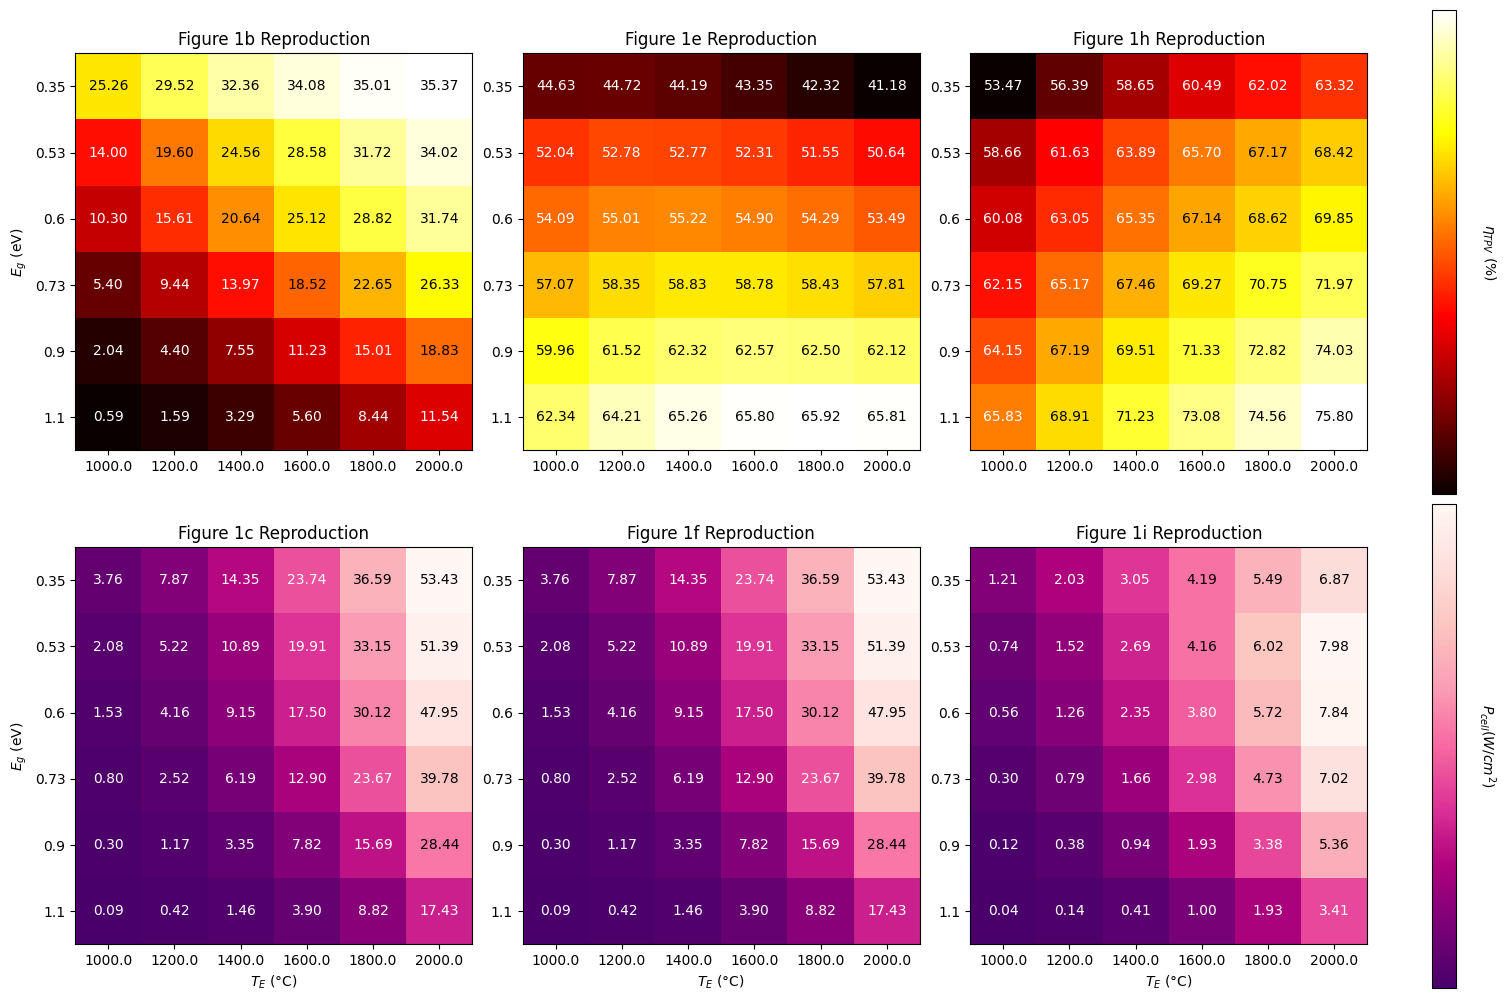

[[ 70.55855856  68.15315315  63.34234234  64.94594595  61.73873874
   60.93693694]
 [107.37737738  98.95562229  98.95562229  95.79746413  96.85018352
   94.74474474]
 [155.27331441 152.52511416 149.7769139  144.28051339 144.28051339
  142.90641326]
 [231.78478478 224.81381381 223.07107107 216.1001001  216.1001001
  212.61461461]
 [294.35764066 290.32534421 284.27689954 278.22845487 276.21230665
  272.1800102 ]
 [673.26512227 657.15830116 644.27284427 631.38738739 624.94465894
  615.28056628]]


In [65]:
#Making the tiles 
fig, ((ax1, ax3, ax5), (ax2, ax4, ax6)) = plt.subplots(2, 3, figsize=(15, 10), constrained_layout = True) 
                                                      #fig -- >blank canvas, ax1 and ax2 are for making P_cell tiles and efficiency tiles, respectively. 
                                                      #subplot dimensions 2,3 means make 2 rows of subplots and have 3 plots in that row. 
                                                      #constrainted_layout was necessary to have 1 shared color bar for each row. 

for ax in (ax1, ax2, ax3, ax4, ax5, ax6):
    ax.set_aspect('equal')

#2 x 2 --> #[[0,0], [0,1]
           # [1,0], [1,1]]
# pcolormesh needs the *edges* of each tile, not the centers,
# so it knows where to draw the tile boundaries

    #Figure 1B
im1 = ax1.pcolormesh(eta_array * 100, cmap='hot') 
ax1.set_title('Figure 1b Reproduction')
#ax1.set_xlabel(r'$T_{E}$ (°C)')
ax1.set_ylabel(r'$E_{g}$ (eV)')
ax1.set_yticks(np.arange(len(Eg_Array)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax1.set_yticklabels(Eg_Array) #this labels the ticks with values stored in Eg_Array
ax1.set_xticks(np.arange(len(T_emitter)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax1.set_xticklabels(np.round(T_emitter - 273.15)) #this labels the ticks with values stored in Eg_Array
#cbar_1 = fig.colorbar(im1, ax=ax1) #uses im1 as reference and plots it on ax1 
#cbar_1.set_label(r'$\eta_{TPV}$ (%)', rotation = 270, labelpad = 30)
                 
threshold = eta_array.max() / 2  
for row in range(len(Eg_Array)):
    for col in range(len(T_emitter)):
        value = eta_array[row, col]
        text_color = 'white' if value < threshold else 'black'
        ax1.text(col + 0.5, row + 0.5, f'{value * 100:.2f}',
                  ha='center', va='center', color=text_color)

    #Figure 1C
im2 = ax2.pcolormesh(P_cell_array, cmap='RdPu_r') #creates the color-mapping based on P_cell_array 
ax2.set_title(r'Figure 1c Reproduction') #this is the P_cell tile plot 
ax2.set_xlabel(r'$T_{E}$ (°C)')
ax2.set_ylabel(r'$E_{g}$ (eV)')
ax2.set_yticks(np.arange(len(Eg_Array)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax2.set_yticklabels(Eg_Array) #this labels the ticks with values stored in Eg_Array
ax2.set_xticks(np.arange(len(T_emitter)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax2.set_xticklabels(np.round(T_emitter - 273.15)) #this labels the ticks with values stored in Eg_Array
#cbar_2 = fig.colorbar(im2, ax=ax2)
#cbar_2.set_label(r'$P_{cell} (W/cm^{2})$', rotation = 270, labelpad = 30) #labelpad just means the amount of space between the label and cbar 

threshold = P_cell_array.max() / 2  # This determines whether the text on the tile is light or dark based on the value. 
for row in range(len(Eg_Array)): #range(len()) --> gives you the indices of the values in a given array, this is needed to properly label each tile  
    for col in range(len(T_emitter)): 
        value = P_cell_array[row, col] #defining a value for the tile 
        text_color = 'white' if value < threshold else 'black' #determines the text color based on threshold 
        ax2.text(col + 0.5, row + 0.5, f'{value:.2f}', #+0.5 to the col and row so that the TEXT is centered in the middle of the row, and then ha and va
                  ha='center', va='center', color=text_color) #ha and va --> horizontal and vertical alignment, respectively, of your textbox. You're telling it to place the
                                                              #center of the textbox at the coordinate (col + 0.5, row + 0.5) 
                                                              #f' string is the text, which is the specific value

    # Figure 1E
im3 = ax3.pcolormesh(eta_array_SBS * 100, cmap='hot') 
ax3.set_title('Figure 1e Reproduction')
#ax3.set_xlabel(r'$T_{E}$ (°C)')
#ax3.set_ylabel(r'$E_{g}$ (eV)')
ax3.set_yticks(np.arange(len(Eg_Array)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax3.set_yticklabels(Eg_Array) #this labels the ticks with values stored in Eg_Array
ax3.set_xticks(np.arange(len(T_emitter)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax3.set_xticklabels(np.round(T_emitter - 273.15)) #this labels the ticks with values stored in Eg_Array
#cbar_3 = fig.colorbar(im3, ax=ax3) #uses im3 as reference and plots it on ax3 
#cbar_3.set_label(r'$\eta_{TPV}$ (%)', rotation = 270, labelpad = 30)
                 
threshold = eta_array_SBS.max() *0.85  
for row in range(len(Eg_Array)):
    for col in range(len(T_emitter)):
        value = eta_array_SBS[row, col]
        text_color = 'white' if value < threshold else 'black'
        ax3.text(col + 0.5, row + 0.5, f'{value * 100:.2f}',
                  ha='center', va='center', color=text_color)


    # Figure 1F
im4 = ax4.pcolormesh(P_cell_array_SBS, cmap='RdPu_r') #creates the color-mapping based on P_cell_array 
ax4.set_title(r'Figure 1f Reproduction') #this is the P_cell tile plot 
ax4.set_xlabel(r'$T_{E}$ (°C)')
#ax4.set_ylabel(r'$E_{g}$ (eV)')
ax4.set_yticks(np.arange(len(Eg_Array)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax4.set_yticklabels(Eg_Array) #this labels the ticks with values stored in Eg_Array
ax4.set_xticks(np.arange(len(T_emitter)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax4.set_xticklabels(np.round(T_emitter - 273.15)) #this labels the ticks with values stored in Eg_Array
#cbar_4 = fig.colorbar(im4, ax=ax4)
#cbar_4.set_label(r'$P_{cell} (W/cm^{2})$', rotation = 270, labelpad = 30) #labelpad just means the amount of space between the label and cbar 

threshold = P_cell_array_SBS.max() / 2  # This determines whether the text on the tile is light or dark based on the value. 
for row in range(len(Eg_Array)): #range(len()) --> gives you the indices of the values in a given array, this is needed to properly label each tile  
    for col in range(len(T_emitter)): 
        value = P_cell_array_SBS[row, col] #defining a value for the tile 
        text_color = 'white' if value < threshold else 'black' #determines the text color based on threshold 
        ax4.text(col + 0.5, row + 0.5, f'{value:.2f}', #+0.5 to the col and row so that the TEXT is centered in the middle of the row, and then ha and va
                  ha='center', va='center', color=text_color) #ha and va --> horizontal and vertical alignment, respectively, of your textbox. You're telling it to place the
                                                              #center of the textbox at the coordinate (col + 0.5, row + 0.5) 
                                                              #f' string is the text, which is the specific value

    #Figure 1h)

#lam_windows = np.zeros((len(Eg_Array), len(T_emitter))) #so that I can determine what the windows are. This will be in [m] 

im5 = ax5.pcolormesh(eta_array_NBE * 100, cmap='hot') 
ax5.set_title('Figure 1h Reproduction')
#ax5.set_xlabel(r'$T_{E}$ (°C)')
#ax5.set_ylabel(r'$E_{g}$ (eV)')
ax5.set_yticks(np.arange(len(Eg_Array)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax5.set_yticklabels(Eg_Array) #this labels the ticks with values stored in Eg_Array
ax5.set_xticks(np.arange(len(T_emitter)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax5.set_xticklabels(np.round(T_emitter - 273.15)) #this labels the ticks with values stored in Eg_Array
cbar_efficiency = fig.colorbar(im5, ax=[ax1, ax3, ax5]) #uses im1 as reference and plots it on ax1 
cbar_efficiency.set_label(r'$\eta_{TPV}$ (%)', rotation = 270, labelpad = 30)
cbar_efficiency.set_ticks([])
                 
threshold = eta_array_NBE.max() * 0.87  
for row in range(len(Eg_Array)):
    for col in range(len(T_emitter)):
        value = eta_array_NBE[row, col]
        text_color = 'white' if value < threshold else 'black'
        ax5.text(col + 0.5, row + 0.5, f'{value * 100:.2f}',
                  ha='center', va='center', color=text_color)
        
    #Figure 1i) 
    
im6 = ax6.pcolormesh(P_cell_array_NBE, cmap='RdPu_r') #creates the color-mapping based on P_cell_array 
ax6.set_title(r'Figure 1i Reproduction') #this is the P_cell tile plot 
ax6.set_xlabel(r'$T_{E}$ (°C)')
#ax6.set_ylabel(r'$E_{g}$ (eV)')
ax6.set_yticks(np.arange(len(Eg_Array)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax6.set_yticklabels(Eg_Array) #this labels the ticks with values stored in Eg_Array
ax6.set_xticks(np.arange(len(T_emitter)) + 0.5) #np.arange(len(Eg_array)) generates len() # of ticks spaced 1 unit apart. the +0.5 shifts the tick positions to be in the center of the tile 
ax6.set_xticklabels(np.round(T_emitter - 273.15)) #this labels the ticks with values stored in Eg_Array
cbar_PCELL = fig.colorbar(im6, ax=[ax2, ax4, ax6])
cbar_PCELL.set_label(r'$P_{cell} (W/cm^{2})$', rotation = 270, labelpad = 30) #labelpad just means the amount of space between the label and cbar
cbar_PCELL.set_ticks([])

threshold = P_cell_array_NBE.max() / 2  # This determines whether the text on the tile is light or dark based on the value. 
for row in range(len(Eg_Array)): #range(len()) --> gives you the indices of the values in a given array, this is needed to properly label each tile  
    for col in range(len(T_emitter)): 
        value = P_cell_array_NBE[row, col] #defining a value for the tile 
        text_color = 'white' if value < threshold else 'black' #determines the text color based on threshold 
        ax6.text(col + 0.5, row + 0.5, f'{value:.2f}', #+0.5 to the col and row so that the TEXT is centered in the middle of the row, and then ha and va
                  ha='center', va='center', color=text_color) #ha and va --> horizontal and vertical alignment, respectively, of your textbox. You're telling it to place the
                                                              #center of the textbox at the coordinate (col + 0.5, row + 0.5) 
                                                              #f' string is the text, which is the specific value

#plt.tight_layout() --> not needed if using constrained layout in the beginning 
plt.show() 

print(lam_windows * 1E9)


In [24]:
print(P_emit_array_SBS)

[[  0.13984274   0.66008931   2.23867222   5.93264455  13.38703277
   26.49227489]
 [  0.50487156   1.90756555   5.36826336  12.50396994  25.10238202
   45.78703514]
 [  1.40679174   4.31160624  10.52919271  21.94592238  40.51705852
   68.80453925]
 [  2.83143657   7.56286566  16.5741117   31.87250603  55.47148136
   89.64930624]
 [  3.99768367   9.89394853  20.64166668  38.05619948  64.29614935
  101.47744938]
 [  8.41524353  17.5938866   32.47116313  54.76220874  86.4615381
  129.76873359]]


C:\Users\bryan\AppData\Local\Temp\ipykernel_32360\2582914648.py:39: RuntimeWarning: overflow encountered in exp
  denominator = (lam)**5 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 )
C:\Users\bryan\AppData\Local\Temp\ipykernel_32360\2582914648.py:69: RuntimeWarning: overflow encountered in exp
  denominator = (lam)**4 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 ) #in units of m^4
C:\Users\bryan\AppData\Local\Temp\ipykernel_32360\2582914648.py:82: RuntimeWarning: overflow encountered in exp
  denominator = (wl)**4 * ( np.exp( (h_J * c) / (wl * kb_J * T) ) - 1 ) #in units of m^4
C:\Users\bryan\AppData\Local\Temp\ipykernel_32360\2482780153.py:117: RuntimeWarning: invalid value encountered in divide
  eta_NBE_vals = P_cell_NBE_vals / P_emit_NBE_cm2 #I'm assuming that it does this element wise to calculate the efficiency at each lam_min value


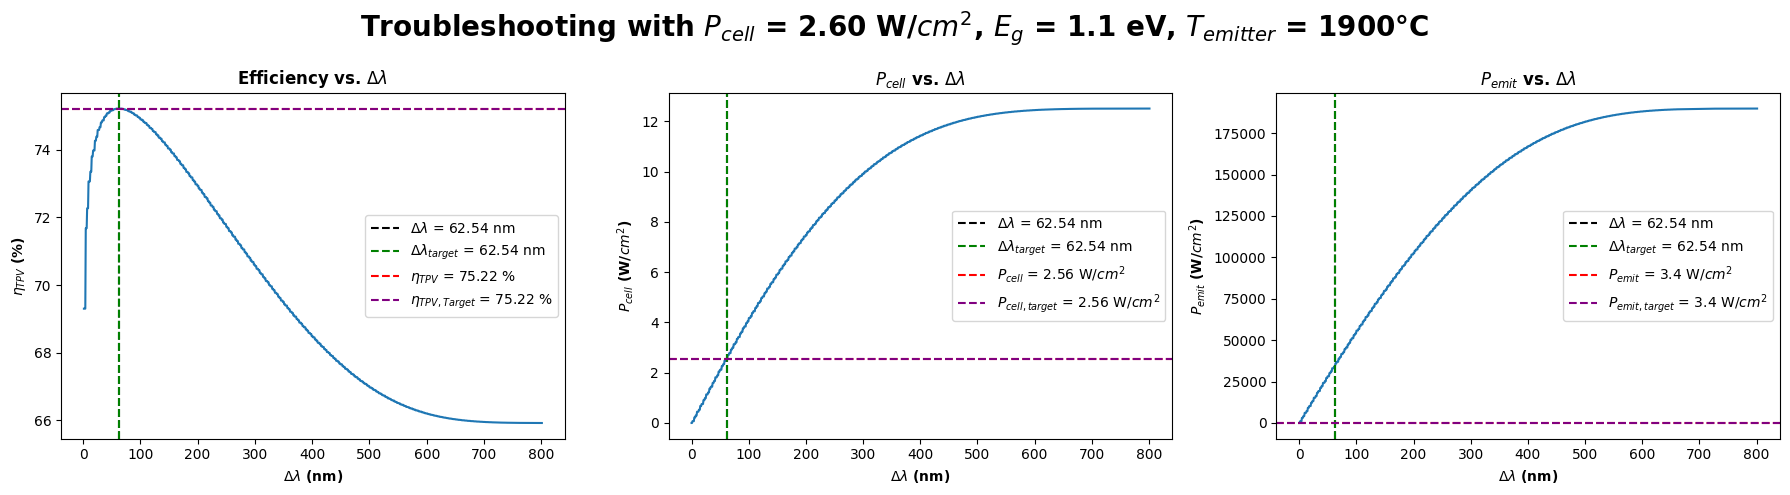

In [63]:
#Troubleshooting -- Trying to see if I can get one of the tiles correct: I'll try working on  Eg = 1.1 eV and T_emitter = 2000 C Tile 

T_emitter_TS = 1900 + 273.15 #2000 C converted to Kelvin, TS = Trouble shoot 

Eg_TS = 1.1 #1.1 eV 

#def bandwidth_maker(lam_min_vals, lam_Eg):
   # for lam_min_value in lam_min_vals:
     #   lam_possible_windows = [] #each row is going to be a bandwidth 
     #   
     #   lam_window_pot = np.linspace(lam_min_value, lam_Eg, 5000)#pot --> potential, this generates a bandwidth containing 5000 elements
        
     #   lam_possible_windows.append(lam_window_pot) 
    
  #  lam_possible_windows = np.array(lam_possible_windows) #okay so each row has 5000 elements in it, but the beginning is different for each one. it will be (lam_min_val * lam_possible_w

  #  return lam_possible_windows 
    

#No need for a loop because we're just testing one combination 

lam_Eg = lam_Bandgap(Eg_TS) # should come out to be in units of meters for the wavelength, determines what portion is sub-bandgap 
        
lam_Eg_nm = lam_Eg * 1E9 #converting it to nm 

lam_min_vals = np.linspace(lam_min, lam_Eg, 1000) #initializing 1000 points, so we're testing 1000 possible windows



    #blackbody spectrum construction

wl_BB_peak = lam_BB_peak(T_emitter_TS) #calculating the peak-wavelength of the spectrum 

wl_array = np.linspace(1E-9, wl_BB_peak * 20, 10000) #wavelength array is also in units of meters, 
                                                     # * 20 and 10000 points achieves good accuracy 

wl_array_nm = wl_array * 1E9 #converting it to nm for later 

#BB_radiance = BB_spectrum(wl_array, T_emitter_TS) #will have units of W / m^3

#BB_radiance_SBS = BB_spectrum_SBS(wl_array, lam_Eg, T_emitter_TS) #BB spectrum w/ sub-bandgap suppression 

    #trying this out specifically just for BB_radiance_NBE 
#windows = bandwidth_maker(lam_min_vals, lam_Eg) 
BB_radiance_NBE = BB_spectrum_NBE(wl_array, lam_min_vals, lam_Eg, T_emitter_TS) # m x n array I think 
                                                            

    #setting things up for integration (simpsons rule approach over scipy.integrate) 

#integrand = np.pi * emissivity * BB_radiance # BB_rad = [W/m^3] --> integrand has units of rad(unitless) * [W/m^3] 

#integrand_SBS = np.pi * emissivity * BB_radiance_SBS #[W/m^3] * rads 

integrand_NBE = np.pi * emissivity * BB_radiance_NBE #same dimensions as BB_radiance_NBE 

#P_emit = simpson(integrand, x = wl_array) #emitted power in units of W/m^2 

#P_emit_SBS = simpson(integrand_SBS, x = wl_array) 

    #also added this in. 

#P_emit_NBE_vals = np.zeros(len(lam_min_vals)) #we're going to have one P_emit for each value in lam_min_vals 

#for k in range(len(lam_min_vals)):
    #P_emit_NBE_vals[k] = simpson(integrand_NBE[k], x = windows[k]) #calculates P_emit for each window 
    
P_emit_NBE_vals = simpson(integrand_NBE, x = wl_array) #again, keep in mind that this is going to be an (m,) array. I need to index into this 
                                                       #with a third index because i belongs to T_emitter and j belongs to Eg_Array

                     
#P_emit_cm2 = P_emit * 1E-4 #emitted power in units of W/cm^2 

#P_emit_SBS_cm2 = P_emit_SBS * 1E-4 #[W/cm^2] 

P_emit_NBE_cm2 = P_emit_NBE_vals * 1E-4 #[W/cm^2] --> These will be the P_emits that I look over. 

#P_emit_array[j,i] = P_emit_cm2

#P_emit_array_SBS[j,i] = P_emit_SBS_cm2 


    #These use the full blackbody spectrum 
#n_B_array_LIGHT = n_B(wl_array, T_emitter_TS) #Blackbody Spectral Photon Radiance, as defined in Declan's slides on 08/02/23.
#n_B_array_DARK = n_B(wl_array, T_c) 

    #These use the spectrum w/ Sub-bandgap suppression
#n_B_array_LIGHT_SBS = n_B_SBS(wl_array, lam_Eg, T_emitter_TS) 
#n_B_array_DARK_SBS = n_B_SBS(wl_array, lam_Eg, T_c) 

    #These use the narrow-band emission BB spectrum 

n_B_array_LIGHT_NBE = n_B_NBE(wl_array, lam_min_vals, lam_Eg, T_emitter_TS) #again, these are m x n arrays 
n_B_array_DARK_NBE = n_B_SBS(wl_array, lam_Eg, T_c) 


EQE_SF = EQE(wl_array_nm, lam_Eg_nm) #this applies only to the cell, so no type of suppression here 

#calculating P_cell for each Spectra and efficiency for each cell 
#P_cell = P_cell_WCM2(n_B_array_LIGHT, n_B_array_DARK, wl_array, EQE_SF, emissivity) #in units of W/cm^2 
#P_cell_SBS = P_cell_WCM2(n_B_array_LIGHT_SBS, n_B_array_DARK_SBS, wl_array, EQE_SF, emissivity)


    #this is one of the things I had to fix. P_cell_WCM2 works only when the n_B arrays are not multidimensional. 
    #when they become multidimensional, that messes up the function output, so we need to loop over every horizontal row/array

P_cell_NBE_vals = np.zeros(len(lam_min_vals)) #1 value for each lam_min

for k in range(len(lam_min_vals)): #k in this case is the index of each lam_min, so we're filling up P_cell properly now 
    P_cell_NBE_vals[k] = P_cell_WCM2(n_B_array_LIGHT_NBE[k], n_B_array_DARK_NBE, wl_array, EQE_SF, emissivity)
                                                
    # should also be (m,) where m = # of lam_min values 
    # Powers are [W/cm^2] 

#eta = P_cell / P_emit_cm2
#eta_SBS = P_cell_SBS / P_emit_SBS_cm2 

eta_NBE_vals = P_cell_NBE_vals / P_emit_NBE_cm2 #I'm assuming that it does this element wise to calculate the efficiency at each lam_min value 


    #now we'll grab the official values for P_cell and P_emit for narrow-band emission 
idx = np.nanargmax(eta_NBE_vals) #index of the largest efficiency value in the array. had to make it nanargmax because with my resolution in trial windows, it was erroring and giving nan 

    #optimized values 
P_cell_TS_max = P_cell_NBE_vals[idx] #[W/cm^2] 
P_emit_TS_max = P_emit_NBE_cm2[idx] #[W/cm^2] 
eta_TS_max = eta_NBE_vals[idx] 
lam_min_optimized = lam_min_vals[idx] 

    #Target values from Declan's paper 
eta_target = 75.80 #in the paper it's listed as 75.8% 
P_cell_target = 2.60 #in the paper it's listed as 3.46 W/cm^2 

#idx_target = np.nanargmin(np.abs(eta_NBE_vals * 100 - eta_target)) #finding where that target value is in my computed values --> if optimized for efficiency 

idx_target = np.nanargmin(np.abs(P_cell_NBE_vals - P_cell_target)) #this is what you get if you try optimizing for P_cell_target 

P_cell_TS_target = P_cell_NBE_vals[idx_target] 
P_emit_TS_target = P_emit_NBE_cm2[idx_target] 
eta_TS_target = eta_NBE_vals[idx_target] 
lam_min_target = lam_min_vals[idx_target]



#Storing the values, all powers are in units of W/cm^2
#P_cell_array[j,i] = P_cell #in units of W/cm^2 
#P_cell_array_SBS[j,i] = P_cell_SBS 
#P_cell_array_NBE[j,i] = P_cell_NBE

#eta_array[j,i] = eta 
#eta_array_SBS[j,i] = eta_SBS 
#eta_array_NBE[j,i] = eta_NBE 

#P_emit_array_NBE[j,i] = P_emit_NBE #[W/cm^2] 
lam_windows = np.abs(lam_min_vals - lam_Eg) #in units of meters, the size of the window
lam_window_TS_optimized = lam_windows[idx] 
lam_window_TS_target = lam_windows[idx_target] 

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Efficiency vs. bandwidth
ax1.plot(lam_windows * 1E9, eta_NBE_vals * 100)
ax1.axvline(lam_window_TS_optimized * 1E9, linestyle='--', color='black',
            label=rf'$\Delta\lambda$ = {np.round(lam_window_TS_optimized * 1E9, 2)} nm')
ax1.axvline(lam_window_TS_target * 1E9, linestyle='--', color='green',
            label=rf'$\Delta\lambda_{{target}}$ = {np.round(lam_window_TS_target * 1E9, 2)} nm')
ax1.axhline(eta_TS_max * 100, linestyle='--', color='red',
            label=rf'$\eta_{{TPV}}$ = {np.round(eta_TS_max * 100, 2)} %')
ax1.axhline(eta_TS_target * 100, linestyle='--', color='purple',
            label=rf'$\eta_{{TPV, Target}}$ = {np.round(eta_TS_target * 100, 2)} %')
ax1.set_xlabel(r'$\Delta\lambda$ (nm)', fontsize=10, fontweight='bold')
ax1.set_ylabel(r'$\eta_{TPV}$ (%)', fontsize=10, fontweight='bold')
ax1.set_title(r'Efficiency vs. $\Delta\lambda$', fontweight='bold')
ax1.legend()

# Panel 2: P_cell vs. bandwidth
ax2.plot(lam_windows * 1E9, P_cell_NBE_vals)
ax2.axvline(lam_window_TS_optimized * 1E9, linestyle='--', color='black',
            label=rf'$\Delta\lambda$ = {np.round(lam_window_TS_optimized * 1E9, 2)} nm')
ax2.axvline(lam_window_TS_target * 1E9, linestyle='--', color='green',
            label=rf'$\Delta\lambda_{{target}}$ = {np.round(lam_window_TS_target * 1E9, 2)} nm')
ax2.axhline(P_cell_TS_max, linestyle='--', color='red',
            label=rf'$P_{{cell}}$ = {np.round(P_cell_TS_max, 2)} W/$cm^{{2}}$')
ax2.axhline(P_cell_TS_target, linestyle='--', color='purple',
            label=rf'$P_{{cell,target}}$ = {np.round(P_cell_TS_target, 2)} W/$cm^{{2}}$')
ax2.set_xlabel(r'$\Delta\lambda$ (nm)', fontsize=10, fontweight='bold')
ax2.set_ylabel(r'$P_{cell}$ (W/$cm^{2}$)', fontsize=10, fontweight='bold')
ax2.set_title(r'$P_{cell}$ vs. $\Delta\lambda$', fontweight='bold')
ax2.legend()

# Panel 3: P_emit vs. bandwidth
ax3.plot(lam_windows * 1E9, P_emit_NBE_vals)
ax3.axvline(lam_window_TS_optimized * 1E9, linestyle='--', color='black',
            label=rf'$\Delta\lambda$ = {np.round(lam_window_TS_optimized * 1E9, 2)} nm')
ax3.axvline(lam_window_TS_target * 1E9, linestyle='--', color='green',
            label=rf'$\Delta\lambda_{{target}}$ = {np.round(lam_window_TS_target * 1E9, 2)} nm')
ax3.axhline(P_emit_TS_max, linestyle='--', color='red',
            label=rf'$P_{{emit}}$ = {np.round(P_emit_TS_max, 2)} W/$cm^{{2}}$')
ax3.axhline(P_emit_TS_target, linestyle='--', color='purple',
            label=rf'$P_{{emit,target}}$ = {np.round(P_emit_TS_target, 2)} W/$cm^{{2}}$')
ax3.set_xlabel(r'$\Delta\lambda$ (nm)', fontsize=10, fontweight='bold')
ax3.set_ylabel(r'$P_{emit}$ (W/$cm^{2}$)', fontsize=10, fontweight='bold')
ax3.set_title(r'$P_{emit}$ vs. $\Delta\lambda$', fontweight='bold')
ax3.legend()

#fig.suptitle(r'Troubleshooting with $\eta_{tpv}$ = 75.6%, $E_{g}$ = 1.1 eV, $T_{emitter}$ = 1900°C', fontsize = 20, fontweight = 'bold') 
fig.suptitle(r'Troubleshooting with $P_{cell}$ = 2.60 W/$cm^{2}$, $E_{g}$ = 1.1 eV, $T_{emitter}$ = 1900°C', fontsize = 20, fontweight = 'bold') 

plt.tight_layout()
plt.show()

In [50]:
print(BB_radiance_NBE)

[[2.38725713e+11 2.38725713e+11 2.38725713e+11 ... 2.38725713e+11
  2.38725713e+11 2.38725713e+11]]
